# Modified Rock Physics Template


This notebook calibrates a modified rock-physics template against Well_2 log data from Quantitative Seismic Interpretation from Per Avseth, et al. It links measured elastic and petrophysical properties to mineral composition, porosity, and fluid saturation, then compares the resulting models with the observed logs.

The workflow starts with a prepared well-log table and moves from data-derived properties to density and velocity calibration, reservoir scenarios, and fluid-saturation estimation.


### Problem Formulation

The objective of this notebook is to derive the rock physics parameters required by the fluid saturation formulation:

$$
S_{fl} =
\frac{
\rho_{ma} + \phi(\rho_w - \rho_{ma})
-
AI
\left[
\frac{1}{V_{p_{ma}}}
-
\phi
\left(
\frac{1}{V_{p_{w}}}
-
\frac{1}{V_{p_{ma}}}
\right)
\right]
}{
\phi
\left[
AI
\left(
\frac{1}{V_{p_{fl}}}
-
\frac{1}{V_{p_{w}}}
\right)
-
(\rho_{fl} - \rho_w)
\right]
}
$$

where the porosity $\phi$ is estimated from:

$$
\phi =
1 -
\left\{
\frac{
V_{s_{sat}}^{2} \rho_{sat}
}{
G^{2} \alpha^{2} V_{p_{ma}}^{2} \rho_{ma}
}
\right\}^{\frac{1}{2n+1}}
$$

Several parameters required by this formulation are not directly obtained from seismic inversion results. Therefore, this notebook focuses on estimating the following rock physics parameters from well data:

$$
\rho_{ma}, \quad V_{p_{ma}}, \quad G, \quad \alpha, \quad n
$$

### Workflow

The workflow is divided into two stages:

1. **Well-data parameterization**  
   Estimate $\rho_{ma}$, $V_{p_{ma}}$, $G$, $\alpha$, and $n$ from the available well-log data.

2. **Seismic application**  
   Use the derived parameters together with seismic inversion results as inputs to the rock physics formulation.

The well-data stage provides a way to investigate whether the proposed parameterization is reasonable at the well scale. However, the resulting parameters are not treated as exact or assumption-free values. Their estimation depends on the available well data, the selected rock physics relationships, and several simplifying assumptions.

Therefore, this notebook also discusses the uncertainties and **grey areas** associated with the parameter estimation. These include cases where the available data are insufficient to uniquely determine a parameter, as well as situations where multiple assumptions may provide physically plausible results.

The final output of this notebook is a set of estimated rock physics parameters:

$$
\boxed{
\rho_{ma},\ V_{p_{ma}},\ G,\ \alpha,\ n
}
$$

These parameters can subsequently be used as inputs for the seismic application. The reliability of that application will depend not only on the parameterization developed here, but also on the quality and limitations of the seismic inversion results.

The purpose of this workflow is therefore not to eliminate uncertainty, but to **make the assumptions explicit and identify where the uncertainty enters the rock physics workflow**.

## Imports


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import itertools
from scipy.stats import pearsonr
from utils import *
from plot_utils import apply_grid_style, styled_scatter, depth_comparison_plot
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import r2_score

## Data loading and derived properties


### Prepare the well-log inputs

**Why this step exists:** Rock-physics calibration requires measured elastic logs and petrophysical descriptors in a common table. This section derives acoustic impedance, shear-related properties, fluid saturation, and mineral-fraction indicators from the prepared Well_2 dataset (look at README.md from Data/ for the explanation of the data), then focuses the analysis on the target depth interval.

**Inputs expected:** `Data/qsiwell2.csv`, containing depth, P-wave velocity (VP), S-wave velocity (VS), bulk density (RHO), porosity (PHI), water saturation (SW), and shale volume (VSH).

**Outputs produced:** A depth-filtered `well` dataset with AI, Vp/Vs, shear modulus, fluid saturation (SFL), and quartz fraction (VQTZ), plus initial log and cross-plot quality checks.

**Connection to the next step:** The derived mineral fractions, porosity, saturation, and density measurements become the calibration inputs for the density model.


In [2]:
well = pd.read_csv("Data/qsiwell2.csv")

well.head()

,DEPTH,VP,VS,RHO_OLD,GR,NPHI,RHO,SW,SWX,VPVS,IP,IS,VSH,RHOm,RHOf,PHI
0,2013.2528,2294.7,876.9,1.9972,91.8785,0.4908,NaN,NaN,NaN,2.616832,NaN,NaN,0.493621,2.728979,NaN,NaN
1,2013.4052,2296.7,943.0,2.0455,86.8004,0.4833,2.240104,1.0,1.0,2.435525,5144.846857,2112.418072,0.436010,2.719762,1.09,0.294312
2,2013.5576,2290.4,912.5,2.1122,86.0021,0.4474,2.242288,1.0,1.0,2.510027,5135.736435,2046.087800,0.426953,2.718313,1.09,0.292342
3,2013.7100,2277.5,891.6,2.1960,87.3570,0.4140,2.242800,1.0,1.0,2.554397,5107.977000,1999.680480,0.442325,2.720772,1.09,0.293096
4,2013.8624,2262.0,890.5,2.2020,90.4024,0.4293,2.240064,1.0,1.0,2.540146,5067.024768,1994.776992,0.476875,2.726300,1.09,0.297156


In [3]:
well['AI'] = well['VP'] * well['RHO'] 
well['mu'] = (well['VS']**2) * well['RHO']
well['VPVS'] = well['VP'] / well['VS']
well['SFL'] = 1 - well['SW']
well['VQTZ'] = 1 - well['VSH']

In [4]:
well = well[(well['DEPTH']>=2100) & (well['DEPTH']<=2400)]
well.head()
print(f'Number of rows with missing values: {well.isna().any(axis=1).sum()}')

Number of rows with missing values: 0


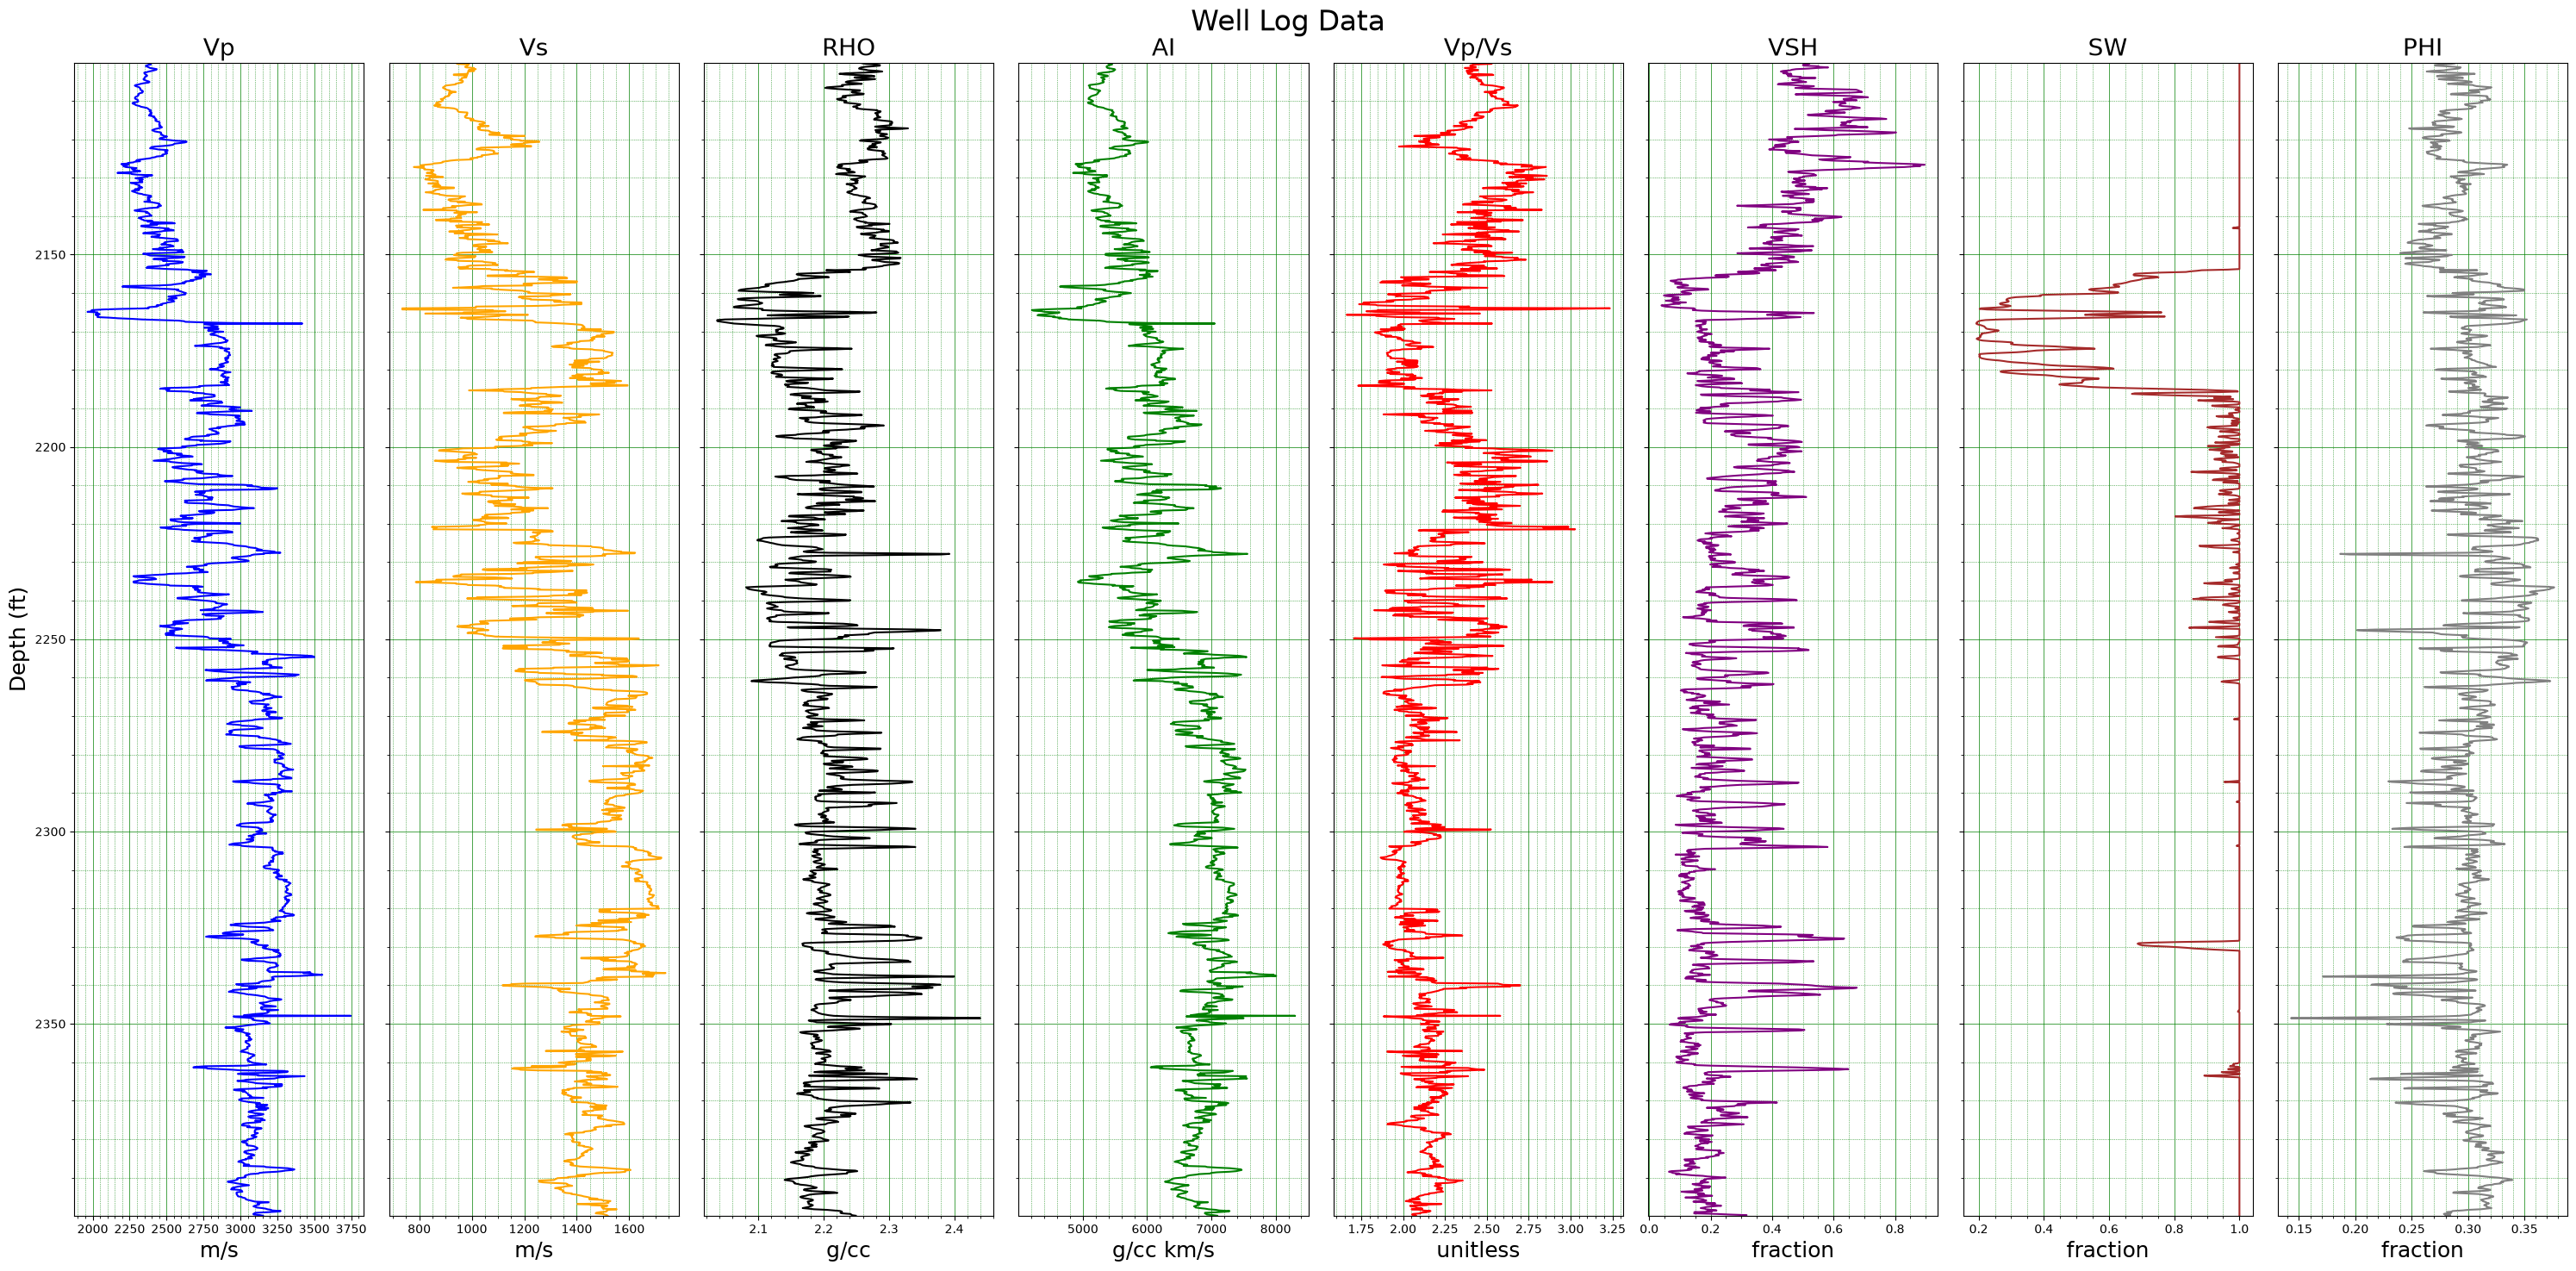

In [5]:
depth_tracks = [
    ("Vp", well['VP'], "blue", "m/s"),
    ("Vs", well['VS'], "orange", "m/s"),
    ("RHO", well['RHO'], "black", "g/cc"),
    ("AI", well['AI'], "green", "g/cc km/s"),
    ("Vp/Vs", well['VPVS'], "red", "unitless"),
    ("VSH", well['VSH'], "purple", "fraction"),
    ("SW", well['SW'], "brown", "fraction"),
    ("PHI", well['PHI'], "grey", "fraction"),
]

fig, ax = plt.subplots(1, len(depth_tracks), figsize=(30, 15), sharey=True)
ax[0].set_ylabel("Depth (ft)", fontsize=18)

for i, (label, series, color, unit) in enumerate(depth_tracks):
    ax[i].set_title(label, fontsize=20)
    ax[i].set_xlabel(unit, fontsize=18)
    ax[i].plot(series, well['DEPTH'], color=color, label=label)
    apply_grid_style(ax[i])
    ax[i].invert_yaxis()
    ax[i].set_ylim(well['DEPTH'].max(), well['DEPTH'].min())

plt.suptitle("Well Log Data", fontsize=24)
plt.tight_layout()
plt.show()

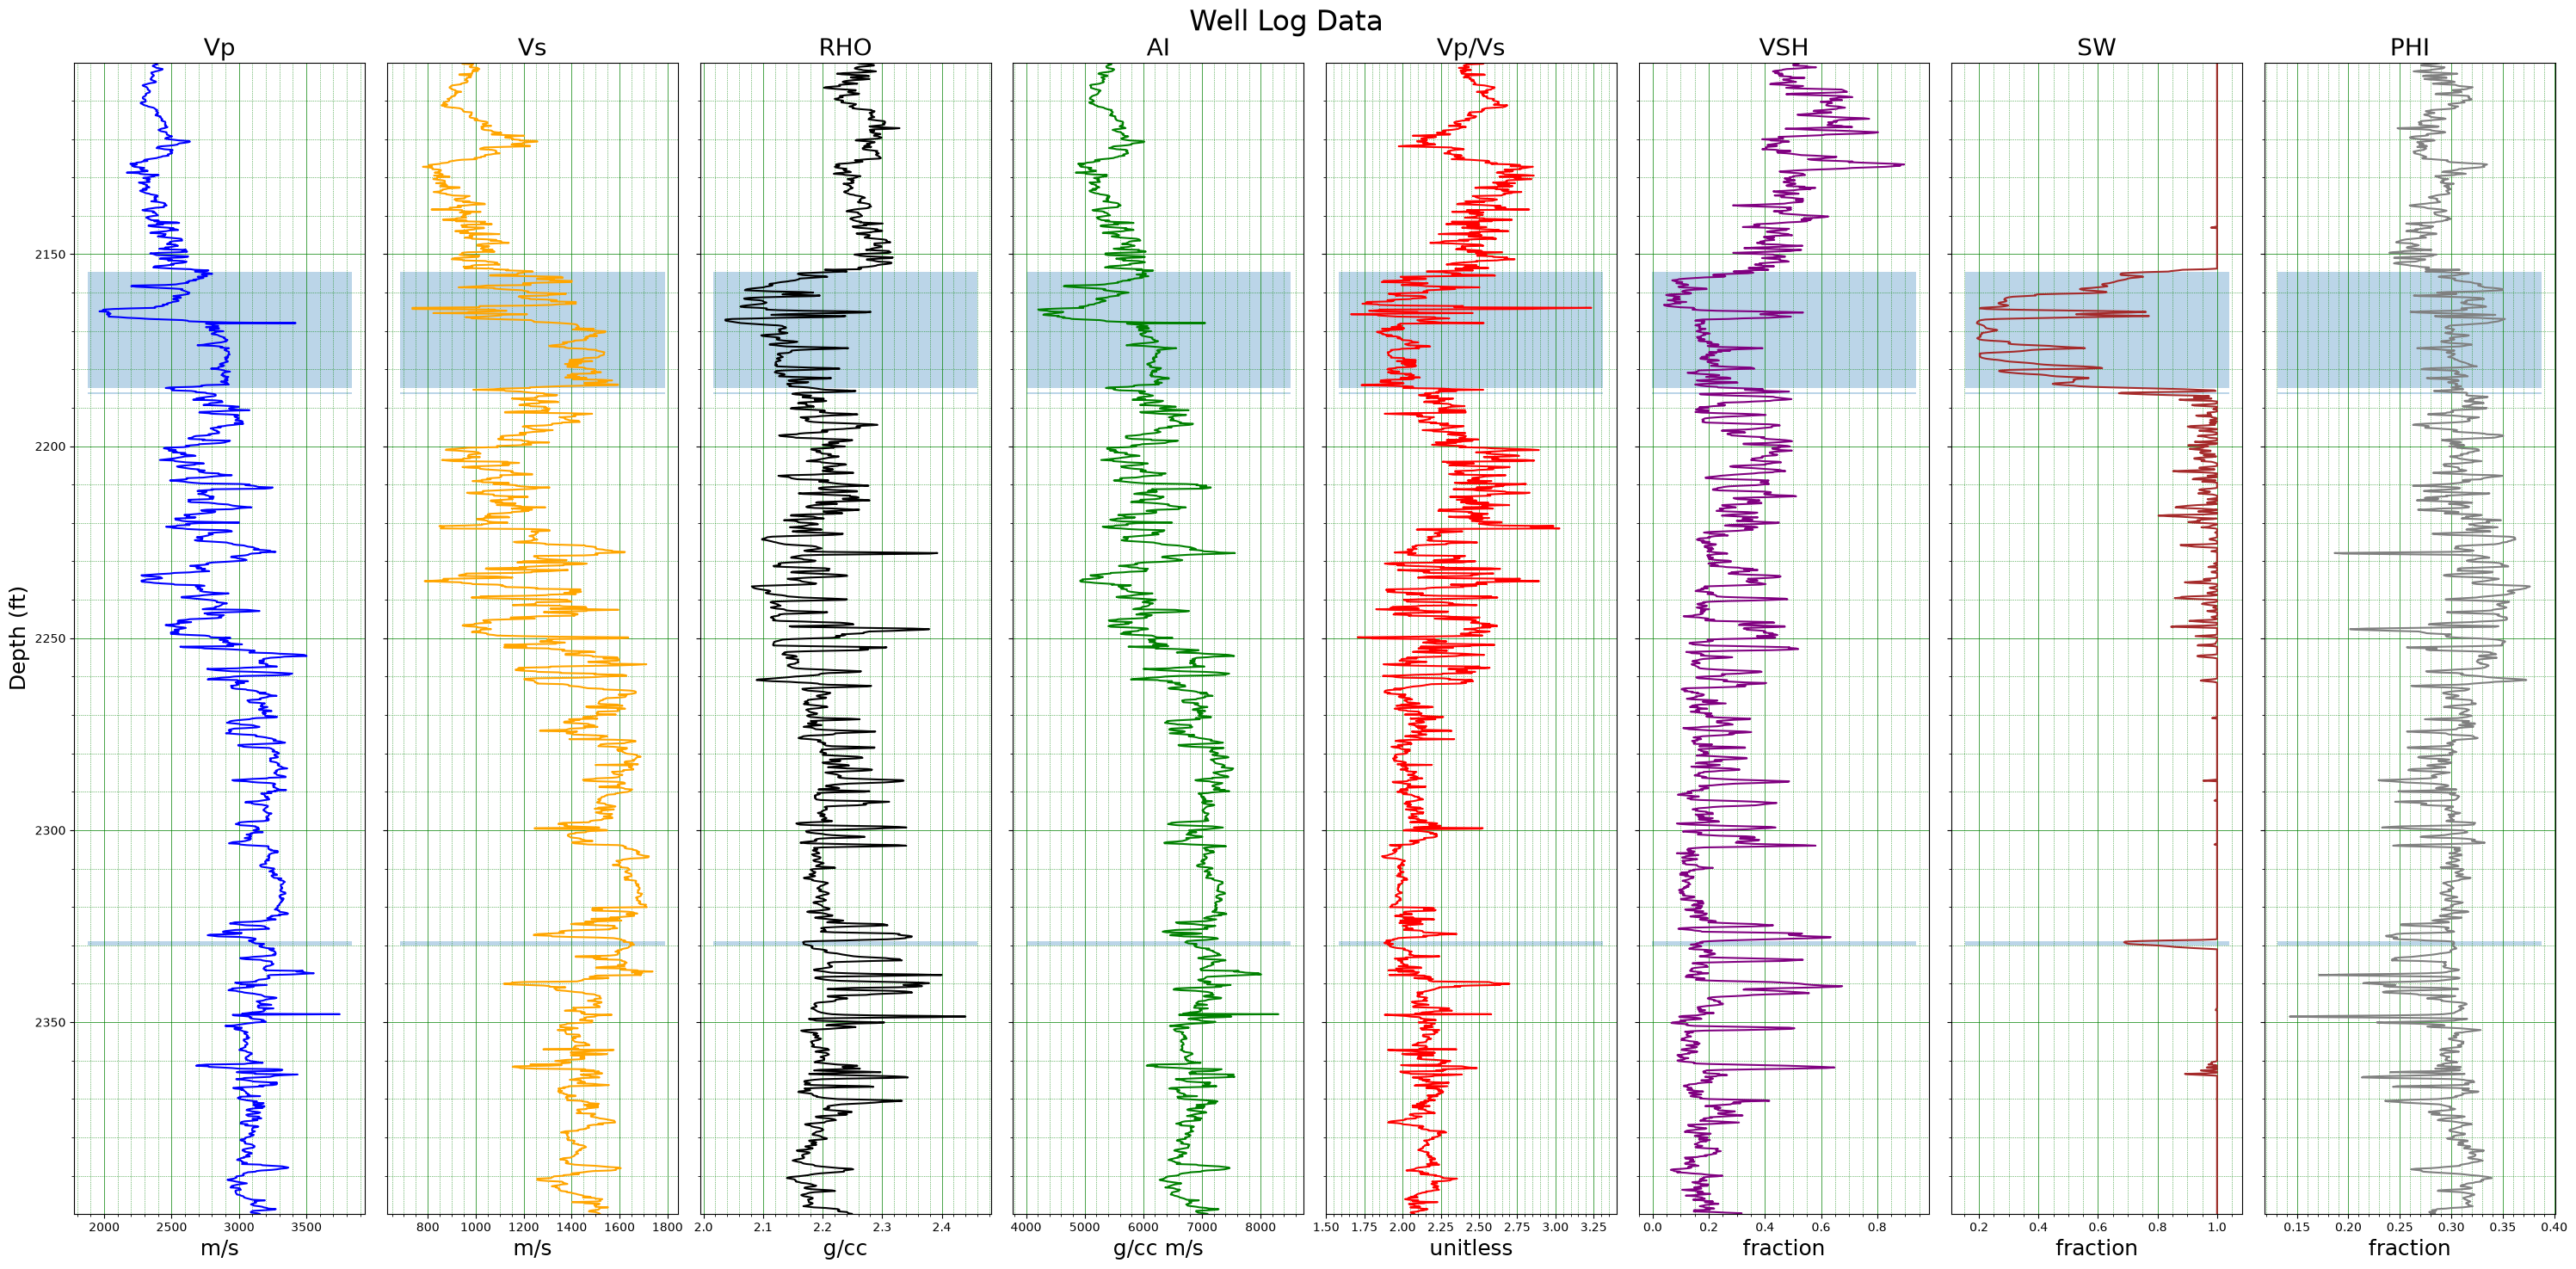

In [6]:
depth_tracks = [
    ("Vp", well["VP"], "blue", "m/s"),
    ("Vs", well["VS"], "orange", "m/s"),
    ("RHO", well["RHO"], "black", "g/cc"),
    ("AI", well["AI"], "green", "g/cc m/s"),
    ("Vp/Vs", well["VPVS"], "red", "unitless"),
    ("VSH", well["VSH"], "purple", "fraction"),
    ("SW", well["SW"], "brown", "fraction"),
    ("PHI", well["PHI"], "grey", "fraction"),
]

low_sw_mask = well["SW"] <= 0.8

fig, ax = plt.subplots(
    1,
    len(depth_tracks),
    figsize=(30, 15),
    sharey=True
)

for i, (label, series, color, unit) in enumerate(depth_tracks):

    ax[i].plot(
        series,
        well["DEPTH"],
        color=color,
        linewidth=1.5
    )

    ax[i].set_title(label, fontsize=20)
    ax[i].set_xlabel(unit, fontsize=18)

    apply_grid_style(ax[i])
    ax[i].invert_yaxis()

    x_min, x_max = ax[i].get_xlim()

    ax[i].fill_betweenx(
        well["DEPTH"],
        x_min,
        x_max,
        where=low_sw_mask,
        alpha=0.3
    )

ax[0].set_ylabel("Depth (ft)", fontsize=18)

ax[0].set_ylim(
    well["DEPTH"].max(),
    well["DEPTH"].min()
)

plt.suptitle("Well Log Data", fontsize=24)

plt.tight_layout()
plt.show()

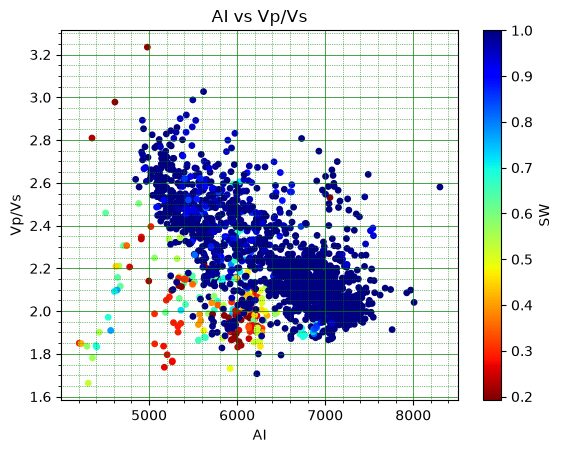

In [7]:
styled_scatter(
    well['AI'], well['VPVS'], well['SW'],
    s=15,
    xlabel="AI", ylabel="Vp/Vs", title="AI vs Vp/Vs", cbar_label="SW", cmap="jet_r"
)
plt.show()

## Density model calibration


### Calibrate matrix density end members

**Why this step exists:** Bulk density is modeled as a combination of mineral matrix and pore-fluid contributions. Calibrating the quartz and shale matrix-density terms provides physically interpretable density inputs for the later reservoir and saturation calculations.

**Inputs expected:** The prepared `well` dataset, especially VQTZ, VSH, RHO, PHI, and SW; water and hydrocarbon density assumptions are retained from the existing analysis.

**Outputs produced:** Regression-based quartz and shale density estimates (`rho_qtz`, `rho_shale`), predicted density tracks, fit diagnostics, and a matrix-density curve (`RHO_MA`).

**Connection to the next step:** The inferred mineral density end members are used with porosity and saturation to interpret velocity behavior and later construct reservoir scenarios.


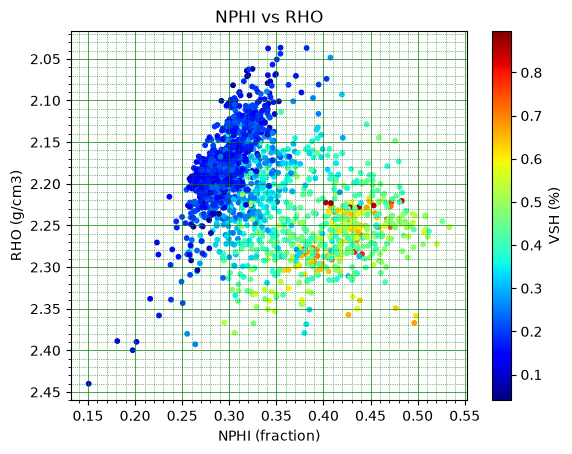

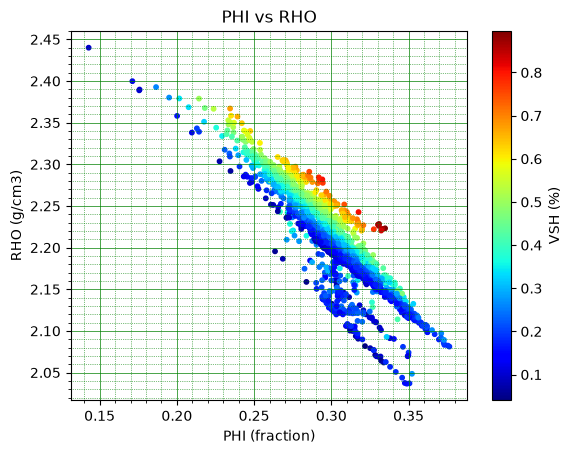

In [8]:
ax, sc = styled_scatter(
    well['NPHI'], well['RHO'], well['VSH'],
    xlabel="NPHI (fraction)", ylabel="RHO (g/cm3)", title="NPHI vs RHO",
    cbar_label="VSH (%)", invert_yaxis=True,
)
plt.show()

styled_scatter(
    well['PHI'], well['RHO'], well['VSH'],
    xlabel="PHI (fraction)", ylabel="RHO (g/cm3)", title="PHI vs RHO",
    cbar_label="VSH (%)",
)
plt.show()

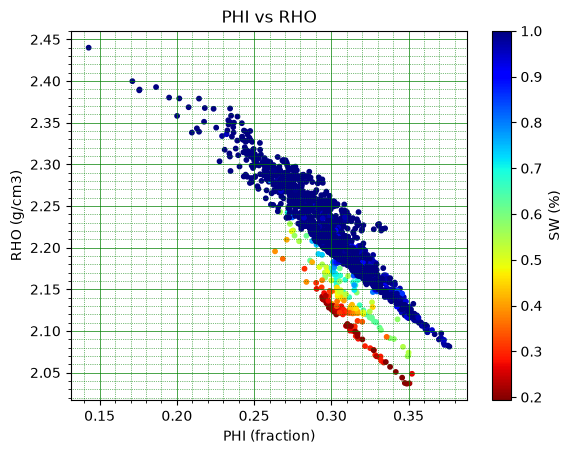

In [46]:
styled_scatter(
    well['PHI'], well['RHO'], well['SW'],
    xlabel="PHI (fraction)", ylabel="RHO (g/cm3)", title="PHI vs RHO",
    cbar_label="SW (%)", cmap="jet_r"
)
plt.show()

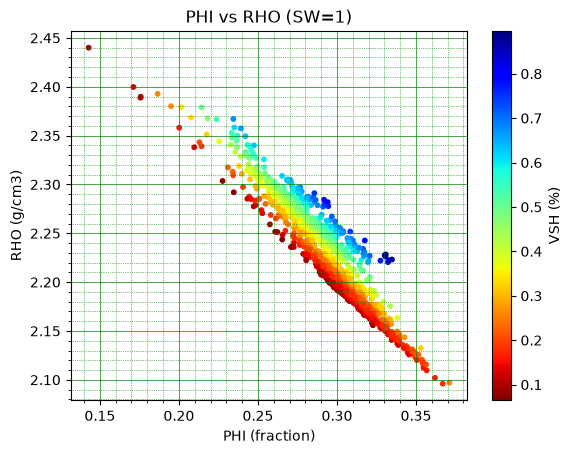

In [47]:
well_SW1 = well[well['SW'] == 1]

styled_scatter(
    well_SW1['PHI'], well_SW1['RHO'], well_SW1['VSH'],
    xlabel="PHI (fraction)", ylabel="RHO (g/cm3)", title="PHI vs RHO (SW=1)",
    cbar_label="VSH (%)", cmap="jet_r"
)
plt.show()

### Method: Multi-linear regression for mineral end members

Multi-linear regression estimates the contribution of more than one predictor to an observed property. Here, quartz fraction (VQTZ) and shale volume (VSH) are used to estimate the mineral-matrix component of bulk density; the same idea is later applied to reciprocal P-wave velocity. This is useful because the well samples span mixed lithologies rather than a single pure mineral, allowing the model coefficients to act as data-calibrated quartz and shale end members.

The method assumes that the chosen predictors represent the relevant mineral mixture, their relationship with the corrected target is approximately linear, and the fluid correction and logged porosity/saturation are adequate. The fitted coefficients are therefore empirical end-member estimates for this well interval, not universal mineral constants. The resulting density end members feed the matrix-density calculation and the later velocity and saturation models.


### Matrix Density Estimation

The density of a saturated rock can be expressed as a volumetric mixture of the matrix and fluid components:

$$
\rho =
\left(
1 - \phi
\right)
\rho_{ma}
+
\phi
\left(
\rho_{w} SW
+
\rho_{fl} S_{fl}
\right)
$$

Since the objective is to estimate the **matrix condition of the rock**, the equation can be rearranged to isolate the matrix density $\rho_{ma}$:

$$
\rho_{ma} =
\frac{
\rho -
\phi
\left(
SW \rho_{w}
+
S_{fl} \rho_{fl}
\right)
}{
1 - \phi
}
$$

The matrix density can then be represented as a volumetric mixture of its constituent minerals:

$$
\rho_{ma} =
\sum \rho_{i} V_{i}
$$

where $\rho_{i}$ and $V_{i}$ represent the density and volume fraction of the $i$-th mineral constituent, respectively.

For the purpose of estimating the matrix composition using **multilinear regression (MLR)**, the fluid component is simplified by considering the fully water-saturated condition, where:

$$
SW = 1
$$

and consequently:

$$
S_{fl} = 0
$$

Under this condition, the matrix density equation becomes:

$$
\rho_{ma} =
\frac{
\rho -
\phi
\left(
SW \rho_{w}
\right)
}{
1 - \phi
}
$$

This simplification allows the MLR to focus on the relationship between the matrix density and its mineral volumetric components, without introducing additional uncertainty from the fluid composition.

Therefore, the MLR in this stage is performed using **volumetric information only**, with the objective of estimating the matrix composition and subsequently deriving $\rho_{ma}$.

In [54]:
X = well_SW1[["VQTZ", "VSH"]]
y = (well_SW1["RHO"] - well_SW1['PHI'] * (well_SW1['SW'] * 1.09)) / (1 - well_SW1['PHI'])


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=27
)

model_without_intercept = LinearRegression(fit_intercept=False)
model_without_intercept.fit(X_train, y_train)

y_pred = model_without_intercept.predict(X_test)

print("Intercept:", model_without_intercept.intercept_)
print("Coefficients:", model_without_intercept.coef_)

for i, col in enumerate(X.columns):
    print(f"{col}: {model_without_intercept.coef_[i]:.4f}")

Intercept: 0.0
Coefficients: [2.65 2.81]
VQTZ: 2.6500
VSH: 2.8100


In [56]:
rho_qtz = model_without_intercept.coef_[0]
rho_shale = model_without_intercept.coef_[1]

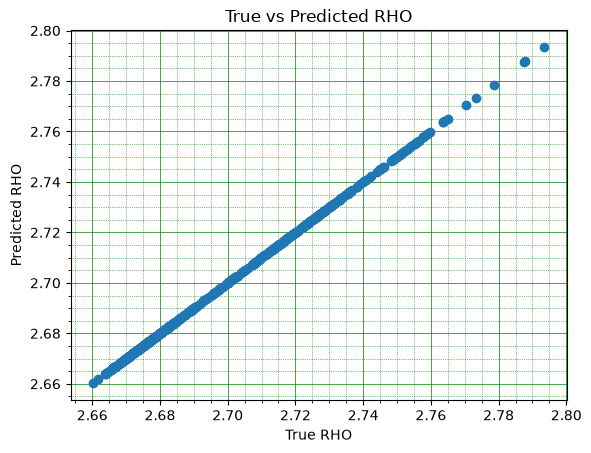

In [57]:
plt.plot(y_test, y_pred, "o")
plt.xlabel("True RHO")
plt.ylabel("Predicted RHO")
plt.title("True vs Predicted RHO")
apply_grid_style()
plt.show()

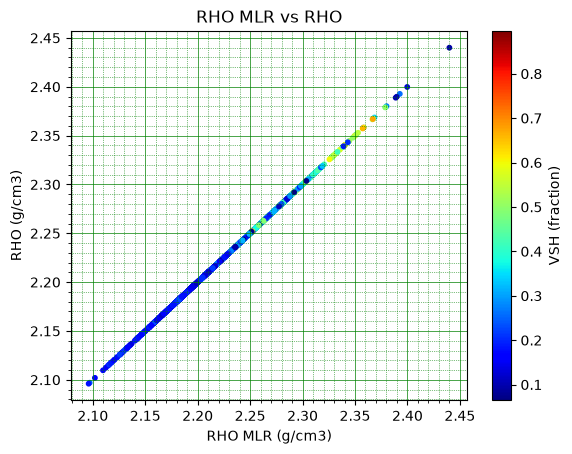

In [59]:
RHO_MLR = model_without_intercept.predict(X) * (1 - well_SW1['PHI']) + well_SW1['PHI'] * well_SW1['SW'] * 1.09 + well_SW1['PHI'] * well_SW1['SFL'] * 0.78
# RHO_MLR_SW1 = RHO_MLR[(well_SW1["SW"] == 1).to_numpy()]

styled_scatter(
    RHO_MLR, well_SW1['RHO'], well_SW1['VSH'],
    xlabel="RHO MLR (g/cm3)", ylabel="RHO (g/cm3)", title="RHO MLR vs RHO",
    cbar_label="VSH (fraction)",
)
plt.show()

Mean Absolute Error: 0.0000
Mean Squared Error: 4.0450e-31
R^2 Score: 1.0000


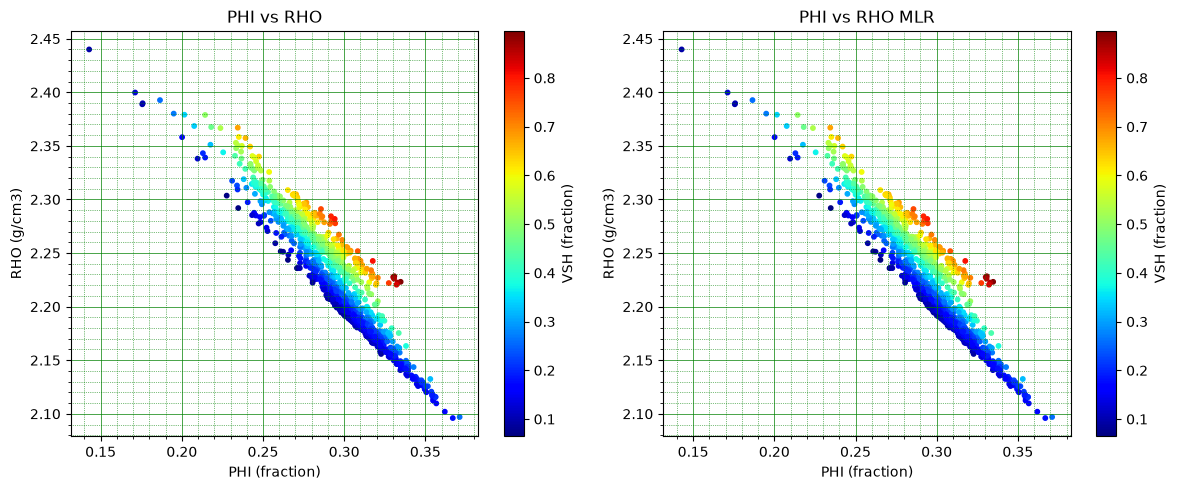

In [60]:
mse = MSE(y_test, y_pred)
mae = MAE(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4e}")
print(f"R^2 Score: {r2:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
styled_scatter(well_SW1['PHI'], well_SW1['RHO'], well_SW1['VSH'], ax=ax[0],
               xlabel="PHI (fraction)", ylabel="RHO (g/cm3)", title="PHI vs RHO",
               cbar_label="VSH (fraction)")
styled_scatter(well_SW1['PHI'], RHO_MLR, well_SW1['VSH'], ax=ax[1],
               xlabel="PHI (fraction)", ylabel="RHO (g/cm3)", title="PHI vs RHO MLR",
               cbar_label="VSH (fraction)")
plt.tight_layout()
plt.show()

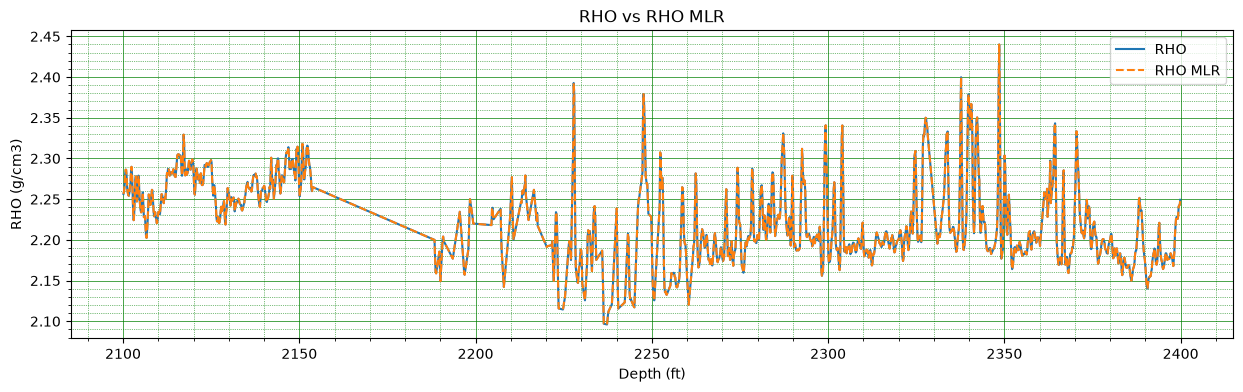

In [65]:
depth_comparison_plot(
    well_SW1['DEPTH'],
    {"RHO": well_SW1['RHO'], "RHO MLR": RHO_MLR},
    xlabel="Depth (ft)", ylabel="RHO (g/cm3)", title="RHO vs RHO MLR",
    linestyles={"RHO MLR": "--"},
)
plt.show()

In [66]:
well['RHO_MA'] = well['VQTZ'] * rho_qtz + well['VSH'] * rho_shale

In [69]:
rho_water = 1.09
for rho_fluid in np.arange(0.6, 0.8, 0.01):
    RHO_Model = (1 - well['PHI']) * well['RHO_MA'] + well['PHI'] * (rho_water * well['SW'] + rho_fluid * (1-well['SW']))
    MAE_RHO = MAE(well['RHO'], RHO_Model)
    print(f"RHO model with fluid density {rho_fluid:.2f} g/cm3: MAE = {MAE_RHO:.5f} g/cm3")

# depth_comparison_plot(
#     well['DEPTH'],
#     {"RHO model": RHO_Model, "RHO": well['RHO']},
#     xlabel="Depth (ft)", ylabel="RHO (g/cm3)", title="RHO Model vs RHO",
# )
plt.show()

RHO model with fluid density 0.60 g/cm3: MAE = 0.00383 g/cm3
RHO model with fluid density 0.61 g/cm3: MAE = 0.00362 g/cm3
RHO model with fluid density 0.62 g/cm3: MAE = 0.00341 g/cm3
RHO model with fluid density 0.63 g/cm3: MAE = 0.00319 g/cm3
RHO model with fluid density 0.64 g/cm3: MAE = 0.00298 g/cm3
RHO model with fluid density 0.65 g/cm3: MAE = 0.00277 g/cm3
RHO model with fluid density 0.66 g/cm3: MAE = 0.00256 g/cm3
RHO model with fluid density 0.67 g/cm3: MAE = 0.00234 g/cm3
RHO model with fluid density 0.68 g/cm3: MAE = 0.00213 g/cm3
RHO model with fluid density 0.69 g/cm3: MAE = 0.00192 g/cm3
RHO model with fluid density 0.70 g/cm3: MAE = 0.00170 g/cm3
RHO model with fluid density 0.71 g/cm3: MAE = 0.00149 g/cm3
RHO model with fluid density 0.72 g/cm3: MAE = 0.00128 g/cm3
RHO model with fluid density 0.73 g/cm3: MAE = 0.00106 g/cm3
RHO model with fluid density 0.74 g/cm3: MAE = 0.00085 g/cm3
RHO model with fluid density 0.75 g/cm3: MAE = 0.00064 g/cm3
RHO model with fluid den

RHO model with fluid density 0.78 g/cm3: MAE = 0.00000 g/cm3


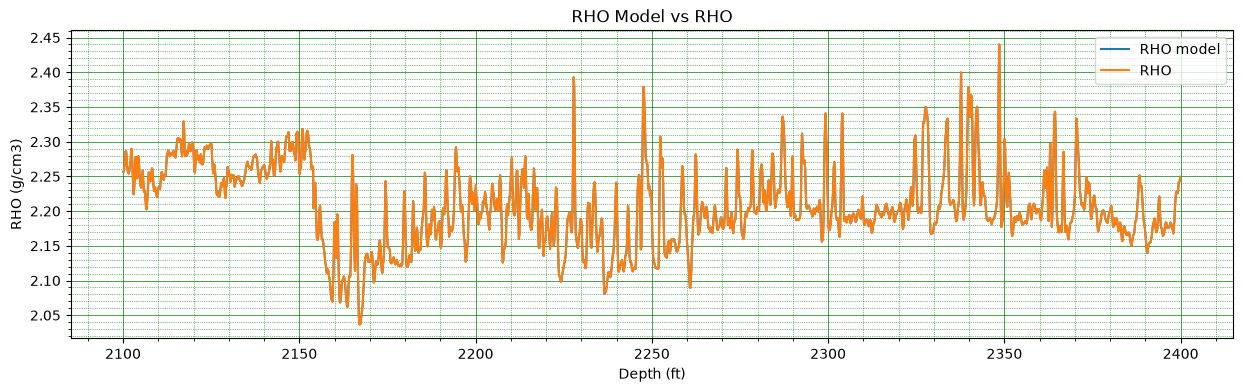

In [68]:
rho_water = 1.09
rho_fluid = 0.78

RHO_Model = (1 - well['PHI']) * well['RHO_MA'] + well['PHI'] * (rho_water * well['SW'] + rho_fluid * (1-well['SW']))
MAE_RHO = MAE(well['RHO'], RHO_Model)
print(f"RHO model with fluid density {rho_fluid:.2f} g/cm3: MAE = {MAE_RHO:.5f} g/cm3")

depth_comparison_plot(
    well['DEPTH'],
    {"RHO model": RHO_Model, "RHO": well['RHO']},
    xlabel="Depth (ft)", ylabel="RHO (g/cm3)", title="RHO Model vs RHO",
)
plt.show()

## Velocity model calibration


### Calibrate P-wave velocity end members and fluid velocity

**Why this step exists:** The template needs P-wave velocity responses for the mineral framework and pore fluids. This section estimates quartz and shale velocity end members, evaluates the velocity model against measured VP, and identifies the fluid-velocity value that minimizes the existing target-interval misfit.

**Inputs expected:** The filtered well data, its fully water-saturated subset (`well_SW1`), VQTZ, VSH, PHI, SW, measured VP, and the brine-velocity assumption.

**Outputs produced:** Regression-derived `Vp_qtz` and `Vp_sh`, a best-fitting `Vp_fluid`, modeled VP curves, MAE diagnostics, and Wyllie-style reference curves.

**Connection to the next step:** These velocity parameters are used to compare calculated shale volume with the existing VSH log and to build the reservoir and saturation templates.


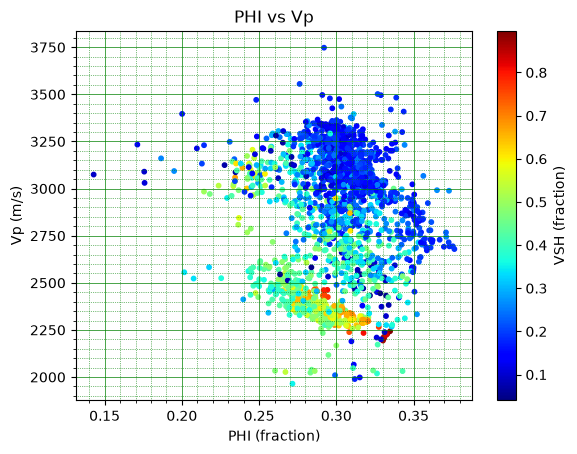

In [21]:
styled_scatter(well['PHI'], well['VP'], well['VSH'],
               xlabel="PHI (fraction)", ylabel="Vp (m/s)", title="PHI vs Vp",
               cbar_label="VSH (fraction)")
plt.show()

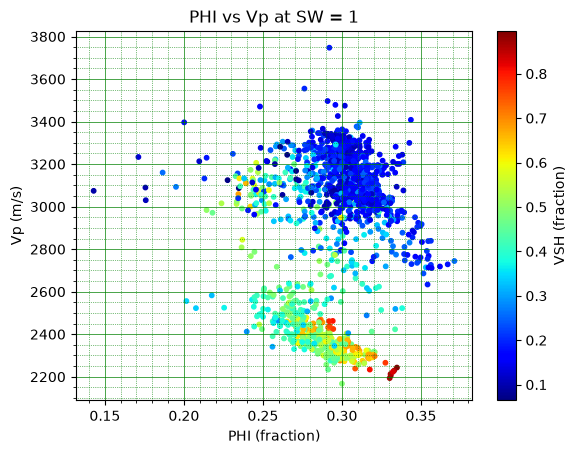

In [22]:
styled_scatter(well_SW1['PHI'], well_SW1['VP'], well_SW1['VSH'],
               xlabel="PHI (fraction)", ylabel="Vp (m/s)", title="PHI vs Vp at SW = 1",
               cbar_label="VSH (fraction)")
plt.show()



In [23]:
K_brine = 2.8e9 
rho_brine = 1090  

Vp_brine = np.sqrt(K_brine / rho_brine)
Vp_water = Vp_brine  
print(f"Vp of water: {Vp_water:.2f} m/s")

Vp of water: 1602.75 m/s


### Matrix P-Wave Velocity Estimation

For the P-wave velocity, the **Wyllie time-average equation** is used to relate the P-wave slowness of the rock to the volumetric contributions of the matrix and fluid components:

$$
\frac{1}{V_{p}} =
\frac{1 - \phi}{V_{p_{ma}}}
+
\frac{\phi SW}{V_{p_{w}}}
+
\frac{\phi S_{fl}}{V_{p_{fl}}}
$$

Similar to the density formulation, the objective is to estimate the **matrix condition of the rock**. Therefore, the equation is rearranged to isolate the matrix P-wave slowness:

$$
\frac{1}{V_{p_{ma}}} =
\frac{
\frac{1}{V_{p}}
-
\frac{\phi SW}{V_{p_{w}}}
}{
1 - \phi
}
$$

The analysis is performed under the same $SW = 1$ condition used in the density estimation. This removes the contribution from the non-water fluid component and allows the analysis to focus on the relationship between the matrix properties and their volumetric composition.

The matrix P-wave slowness can then be represented as a volumetric mixture of the constituent minerals:

$$
\frac{1}{V_{p_{ma}}} =
\sum
\frac{V_{i}}{V_{p_{i}}}
$$

where $V_{i}$ represents the volume fraction of the $i$-th mineral and $V_{p_{i}}$ represents its P-wave velocity.

This formulation provides a linear relationship between the matrix P-wave slowness and the mineral volume fractions. Therefore, multilinear regression can be applied to estimate the mineral contributions and subsequently derive $V_{p_{ma}}$.

In [24]:
X_VP = well_SW1[["VQTZ", "VSH"]]
y_VP = (1 / well_SW1["VP"] - well_SW1["PHI"] * well_SW1["SW"] / Vp_water) / (1 - well_SW1["PHI"]) 

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, QuantileRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X_VP, y_VP, test_size=0.1, random_state=27
)

model_Vp = LinearRegression(fit_intercept=False)
model_Vp.fit(X_VP, y_VP)

# model_Vp = QuantileRegressor(quantile=0.5, alpha=0)  
# model_Vp.fit(X_VP, y_VP)

y_pred = model_Vp.predict(X_VP)

print("Intercept:", model_Vp.intercept_)
print("Coefficients:", model_Vp.coef_)

for i, col in enumerate(X_VP.columns):
    print(f"{col}: {model_Vp.coef_[i]}")

Intercept: 0.0
Coefficients: [0.00013516 0.0004653 ]
VQTZ: 0.0001351583596301527
VSH: 0.0004653030951432764


In [26]:
Y = model_Vp.predict(X_VP)
one_over_Vp_MLR = Y * (1 - well_SW1['PHI']) + (well_SW1['PHI'] / Vp_water)
Vp_MLR = 1 / one_over_Vp_MLR

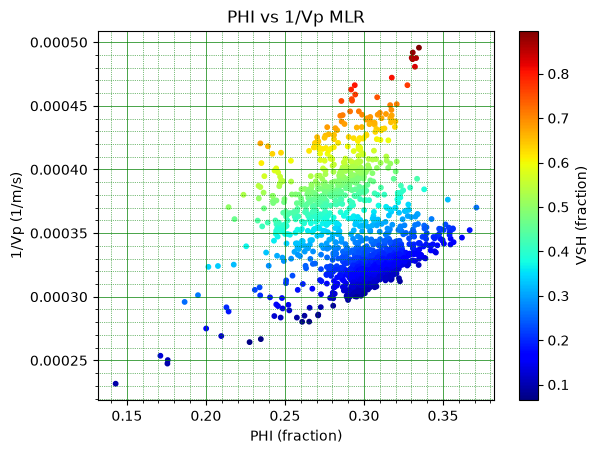

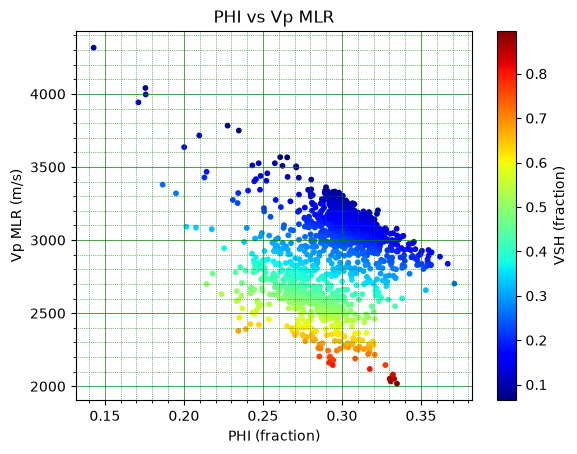

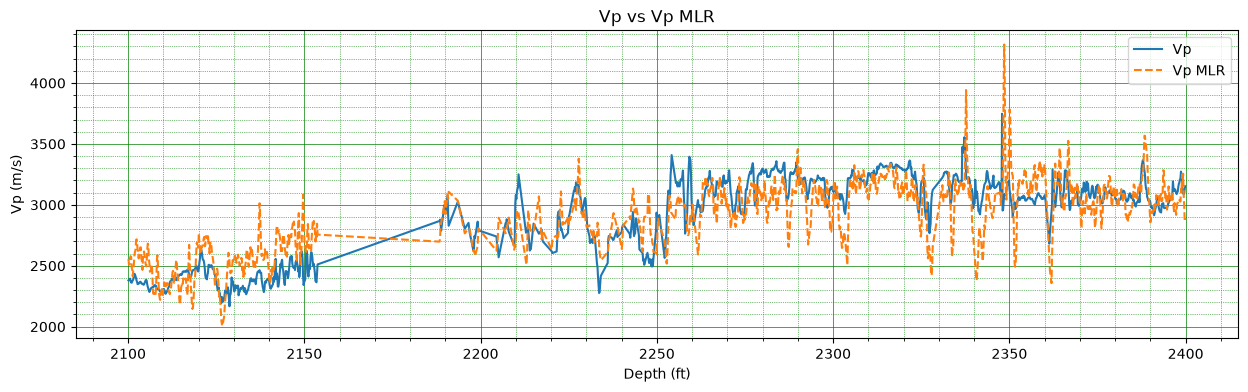

Mean Absolute Error for Vp MLR: 163.9543


In [27]:
styled_scatter(well_SW1['PHI'], one_over_Vp_MLR, well_SW1['VSH'],
               xlabel="PHI (fraction)", ylabel="1/Vp (1/m/s)", title="PHI vs 1/Vp MLR",
               cbar_label="VSH (fraction)")
plt.show()

styled_scatter(well_SW1['PHI'], Vp_MLR, well_SW1['VSH'],
               xlabel="PHI (fraction)", ylabel="Vp MLR (m/s)", title="PHI vs Vp MLR",
               cbar_label="VSH (fraction)")
plt.show()

depth_comparison_plot(
    well_SW1['DEPTH'],
    {"Vp": well_SW1['VP'], "Vp MLR": Vp_MLR},
    xlabel="Depth (ft)", ylabel="Vp (m/s)", title="Vp vs Vp MLR",
    linestyles={"Vp MLR": "--"},
)

mae_Vp_MLR = MAE(well_SW1['VP'], Vp_MLR)
print(f"Mean Absolute Error for Vp MLR: {mae_Vp_MLR:.4f}")

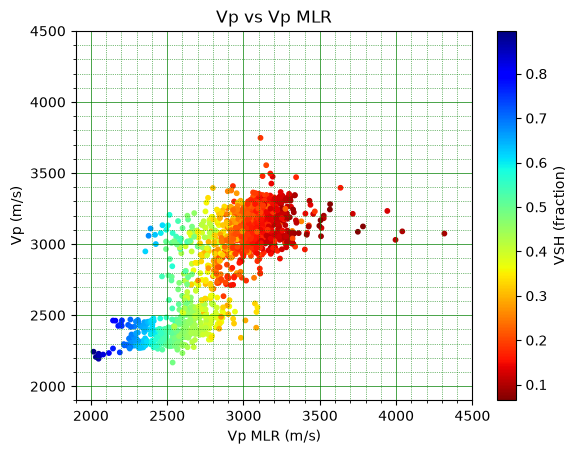

In [28]:
ax, sc = styled_scatter(Vp_MLR, well_SW1['VP'], well_SW1['VSH'],
                         xlabel="Vp MLR (m/s)", ylabel="Vp (m/s)", title="Vp vs Vp MLR",
                         cbar_label="VSH (fraction)", cmap="jet_r")
ax.set_xlim(1900, 4500)
ax.set_ylim(1900, 4500)
plt.show()

In [29]:
Vp_qtz = 1 / model_Vp.coef_[0]
Vp_sh = 1 / model_Vp.coef_[1]

print(f"Vp_qtz: {Vp_qtz:.2f} m/s")
print(f"Vp_sh: {Vp_sh:.2f} m/s")


Vp_qtz: 7398.73 m/s
Vp_sh: 2149.14 m/s


In [30]:
Vp_ma_full = (1 - well['VSH']) * Vp_qtz + (well['VSH']) * Vp_sh

In [31]:
mask_VP = (well['DEPTH'] >= 2154) & (well['DEPTH'] <= 2190)

In [32]:
df_Vp_fluid = []
for Vp_fluid in np.arange(1100, 1500.1, 0.1):
    Vp_matrix = 1 / (((1 - well['VSH']) / Vp_qtz) + (well['VSH'] / Vp_sh)) 
        
    Vp = (((1 - well['PHI']) / Vp_matrix) + (well['PHI'] * well['SW'] / Vp_water) + (well['PHI'] * (1 - well['SW']) / Vp_fluid)) ** -1
    mae = MAE(well['VP'][mask_VP], Vp[mask_VP])
    df_Vp_fluid.append([Vp_fluid, mae])

df_Vp_fluid = pd.DataFrame(df_Vp_fluid, columns=["Vp_fluid", "MAE"])
best_Vp_fluid = df_Vp_fluid.loc[df_Vp_fluid["MAE"].idxmin()]
print(f"Best Vp_fluid: {best_Vp_fluid['Vp_fluid']:.2f} m/s with MAE: {best_Vp_fluid['MAE']:.4f}")
Vp_fluid = best_Vp_fluid['Vp_fluid']

Best Vp_fluid: 1312.10 m/s with MAE: 221.3175


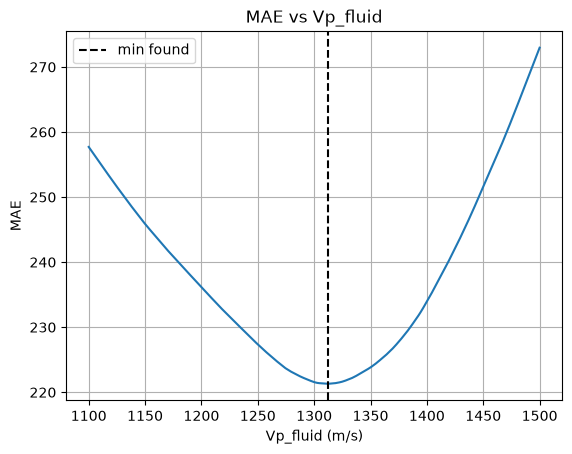

In [33]:
import matplotlib.pyplot as plt

plt.plot(df_Vp_fluid['Vp_fluid'], df_Vp_fluid['MAE'])
plt.xlabel('Vp_fluid (m/s)')
plt.ylabel('MAE')
plt.title('MAE vs Vp_fluid')
plt.grid(True)
plt.axvline(df_Vp_fluid['Vp_fluid'].iloc[df_Vp_fluid['MAE'].idxmin()], color='k', linestyle='--', label='min found')
plt.legend()
plt.show()


<!-- TODO: Confirm whether this VSH comparison should use the regression-derived Vp end members below or the modulus-derived end members used later for the saturation model. -->


## Wyllie template and reservoir scenarios


### Build reference trends for reservoir behavior

**Why this step exists:** Reference trends show how P-wave velocity, acoustic impedance, and Vp/Vs vary with porosity, shale content, and fluid state. They provide the rock-physics context for interpreting the observed well data.

**Inputs expected:** Calibrated mineral density and velocity end members, fluid velocity and density assumptions, porosity, VSH, SW, and observed Well_2 elastic and petrophysical logs.

**Outputs produced:** Wyllie-style velocity trends, reservoir-focused cross-plots for two shale-volume filters, acoustic-impedance bounds, and the reservoir matrix velocity/density used later.

**Connection to the next step:** The selected matrix and fluid properties supply the physical inputs for the Pranatikta fluid-saturation parameter search.


### Method: Wyllie's Time Average equation

Wyllie's Time Average equation represents the reciprocal of P-wave velocity (slowness) as a porosity-weighted mixture of matrix and pore-fluid slowness. In this project it is extended with quartz and shale fractions so that the matrix velocity changes with shale content. The equation is used to generate reference velocity trends and to compare observed VP with the response expected from porosity, lithology, and fluid state.

Its key assumptions are a linear mixing relationship in slowness, a representative matrix velocity for the specified shale fraction, and uniform pore-fluid velocities. It is most appropriate as a first-order reference trend; effects such as pore geometry, cementation, pressure, anisotropy, and dispersion are not explicitly modeled. The generated Wyllie trends provide the reservoir-template context used before fluid-saturation estimation.


0.0
Vp matrix for VSH 0.0 : 7398.73 m/s
0.2
Vp matrix for VSH 0.2 : 4970.49 m/s
0.4
Vp matrix for VSH 0.4 : 3742.29 m/s
0.6000000000000001
Vp matrix for VSH 0.6 : 3000.79 m/s
0.8
Vp matrix for VSH 0.8 : 2504.54 m/s
1.0
Vp matrix for VSH 1.0 : 2149.14 m/s


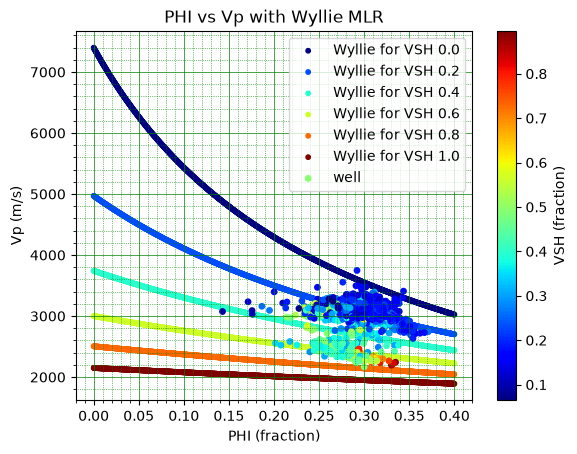

In [34]:
phi = np.linspace(0, 0.4, len(well_SW1['VSH']))
al = np.arange(0, 1.1, 0.2)

for vsh_vp in al:
    print(vsh_vp)
    wyllie_MLR = (
        (1 - phi) * (((1 - vsh_vp) / Vp_qtz) + (vsh_vp / Vp_sh)) + phi / Vp_water
    ) ** -1
    plt.scatter(
        phi,
        wyllie_MLR,
        c=vsh_vp * np.ones_like((wyllie_MLR)),
        cmap="jet",
        label=f"Wyllie for VSH {vsh_vp:.1f}",
        s=10,
        vmin=0,
        vmax=1,
    )
    print(f"Vp matrix for VSH {vsh_vp:.1f} : {max(wyllie_MLR):.2f} m/s")


plt.scatter(well_SW1['PHI'], well_SW1['VP'], c=well_SW1['VSH'], cmap="jet", s=15, label="well")
plt.xlabel("PHI (fraction)")
plt.ylabel("Vp (m/s)")
plt.title("PHI vs Vp with Wyllie MLR")
plt.colorbar(label="VSH (fraction)")
plt.legend()
apply_grid_style()
plt.show()

### Reservoir shale-volume filter

**Why this step exists:** This scenario isolates samples with relatively low to moderate shale volume so the reservoir reference trend can be compared with a cleaner portion of the well.

**Inputs expected:** The filtered `well` dataset, its VSH curve, porosity, saturation, and the calibrated mineral and fluid velocity values.

**Outputs produced:** Reservoir-focused velocity and cross-plot comparisons for the retained shale-volume range.

**Connection to the next step:** The resulting reservoir matrix properties and template bounds are carried into the fluid-saturation model.


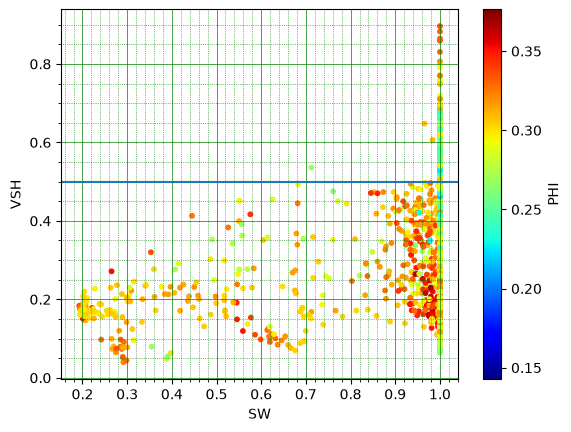

In [35]:
styled_scatter(x=well['SW'], xlabel='SW', 
               y=well['VSH'], ylabel='VSH', 
               c=well['PHI'], cbar_label='PHI')
plt.axhline(y=0.5)
plt.show()

Vp matrix at reservoir: 4593.59 m/s


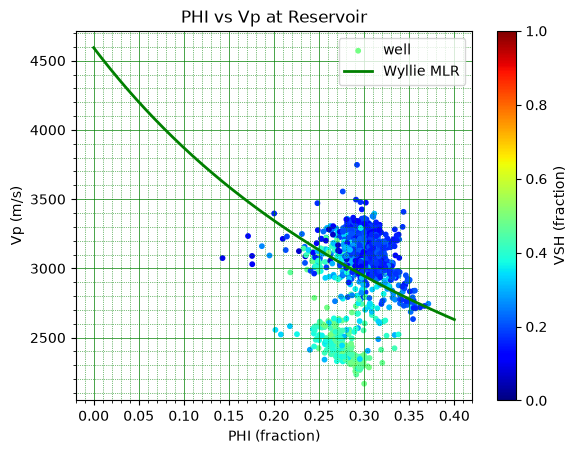

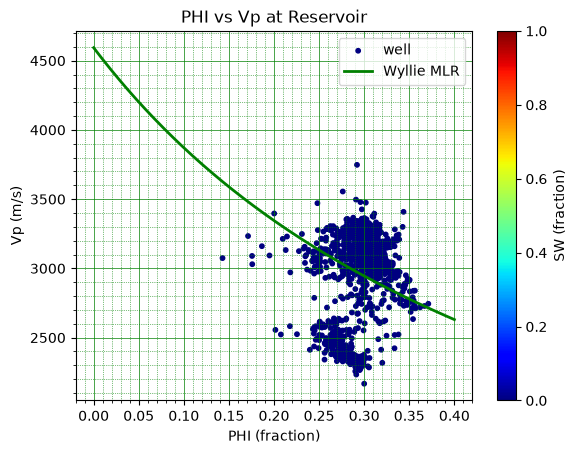

In [ ]:
df_0SW1_0Vsh = well_SW1[(well_SW1["VSH"] < .5) & (well_SW1["VSH"] > 0.0)]
phi_reservoir = np.linspace(0, 0.4, len(df_0SW1_0Vsh["VSH"]))
Vp_at_reservoir = wyllie_with_vsh(
    porosity=phi_reservoir,
    Vsh=0.25,
    SW=1,
    Vp_qtz=Vp_qtz,
    Vp_shale=Vp_sh,
    Vp_water=Vp_water,
    Vp_hc=Vp_fluid,
)
Vp_matrix_reservoir = max(Vp_at_reservoir)
print(f"Vp matrix at reservoir: {Vp_matrix_reservoir:.2f} m/s")
plt.scatter(
    df_0SW1_0Vsh["PHI"],
    df_0SW1_0Vsh["VP"],
    c=df_0SW1_0Vsh["VSH"],
    cmap="jet",
    s=10,
    label="well",
    vmin=0,
    vmax=1,
)
Vp_wyllie_lama = (((1-phi_reservoir) / Vp_qtz) + (phi_reservoir / Vp_water)) ** -1
plt.plot(phi_reservoir, Vp_at_reservoir, color="g", linewidth=2, label="Wyllie MLR")
plt.xlabel("PHI (fraction)")
plt.ylabel("Vp (m/s)")
plt.title("PHI vs Vp at Reservoir")
plt.colorbar(label="VSH (fraction)")
plt.legend()
apply_grid_style()
plt.show()

plt.scatter(
    df_0SW1_0Vsh["PHI"],
    df_0SW1_0Vsh["VP"],
    c=1 - df_0SW1_0Vsh["SW"],
    cmap="jet",
    s=10,
    label="well",
    vmin=0,
    vmax=1,
)
plt.plot(phi_reservoir, Vp_at_reservoir, color="g", linewidth=2, label="Wyllie MLR")
plt.xlabel("PHI (fraction)")
plt.ylabel("Vp (m/s)")
plt.title("PHI vs Vp at Reservoir")
plt.colorbar(label="SW (fraction)")
plt.legend()
apply_grid_style()
plt.show()

**Note:** The cross-plot above shows the reservoir interval is reasonably bounded by VSH < 0.5. To represent a single, characteristic value within that range, VSH = 0.25 is used as the reservoir shale-volume fraction for the remaining Wyllie and saturation calculations.

In [37]:
Vsh_reservoir = 0.25
rho_reservoir = rho_qtz * (1 - Vsh_reservoir) + rho_shale * Vsh_reservoir
AI_reservoir = Vp_at_reservoir * rho_reservoir
print(AI_reservoir.min())
print(AI_reservoir.max())

7075.4508538001355
12356.763548810712


## Pranatikta fluid-saturation model


### Estimate fluid saturation and compare rock-physics templates

**Why this step exists:** This final stage searches the existing Pranatikta/Krishna-model parameter ranges to find the fluid-saturation response that best matches the saturation inferred from the well log. It then compares the fitted response with observed elastic behavior in AI–Vp/Vs space.

**Inputs expected:** Target-interval well logs (VP, VS, RHO, AI, SW, PHI, VSH), calibrated mineral/fluid properties, reservoir matrix properties, and the existing search ranges for `N`, `alpha`, and VSH.

**Outputs produced:** Best-fitting Pranatikta parameters, modeled fluid saturation, saturation-versus-depth comparisons, AI–Vp/Vs comparison plots, and synthetic template curves across porosity and saturation.

**Connection to the next step:** This is the terminal interpretation stage: its fitted parameters and comparison plots summarize how well the modified rock-physics template represents the Well_2 interval.


### Method: Modified Fawad-Mondol Rock Physics Template

The modified Fawad-Mondol rock-physics template links porosity, elastic velocities, density, acoustic impedance, Vp/Vs, shale content, and fluid saturation. In this notebook, mineral elastic properties define the matrix response, the porosity relation controls the shear-wave behavior, and the fluid-saturation relation is evaluated against the saturation log. A parameter search identifies the existing template settings that minimize mismatch to the observed Well_2 response.

The method assumes that the selected quartz–shale matrix, water–hydrocarbon fluid properties, and empirical porosity/shear parameters represent the target interval. It also assumes that the well-log saturation is an appropriate calibration reference and that a single parameter set can describe the evaluated interval. The fitted template is then used to compare modeled and observed fluid saturation and AI–Vp/Vs behavior.


In [38]:
N_params = np.arange(0.1, 2.51, 0.01).astype(np.float32)
alpha_params = np.arange(0.2, 0.6, 0.01).astype(np.float32)
# Vsh_params = np.arange(0.2, 0.6, 0.01).astype(np.float32)

parameter_combinations_porosity = itertools.product( N_params, alpha_params, 
                                                    # Vsh_params
                                                    )
results_Sfl_pranatikta = []


rho_fluid = 0.78  # g/cm3
rho_water = 1.09  # g/cm3

rho_matrix_vsh = rho_qtz * (1 - Vsh_reservoir) + rho_shale * Vsh_reservoir
G = 1


for  N, alpha in parameter_combinations_porosity:
    Vp_matrix_vsh = wyllie_with_vsh(
    porosity=0,
    Vsh=Vsh_reservoir,
    SW=1,
    Vp_qtz=Vp_qtz,
    Vp_shale=Vp_sh,
    Vp_water=Vp_water,
    Vp_hc=Vp_fluid)
    
    
    pranatikta_porosity = porosityKrishna(
        Vp_matrix=Vp_matrix_vsh,
        Vs_saturated=well['VS'],
        rho_saturated=well['RHO'],
        rho_matrix=rho_matrix_vsh,
        alpha=alpha,
        G=1,
        N=N,
    )

    Sfl_pranatikta = FluidSaturation(
        rho_matrix=rho_matrix_vsh,
        rho_fluid=rho_fluid,
        rho_water=rho_water,
        Vp_matrix=Vp_matrix_vsh,
        Vp_fluid=Vp_fluid,
        Vp_water=Vp_water,
        porosity=pranatikta_porosity,
        AI=well['AI'],
    ).astype(np.float32)

    misfit_pranatikta = MSE(Sfl_pranatikta, (1 - well['SW']))

    results_Sfl_pranatikta.append([G, N, alpha, Sfl_pranatikta, misfit_pranatikta])

results_Sfl_pranatikta_df = pd.DataFrame(
    results_Sfl_pranatikta,
    columns=["G", "N", "alpha", "Sfl_pranatikta", "misfit_pranatikta"],
)
misfit_map = np.copy(results_Sfl_pranatikta_df["misfit_pranatikta"])

results_Sfl_pranatikta_df = results_Sfl_pranatikta_df.sort_values(
    "misfit_pranatikta", ascending=True
)
best_params_pranatikta = results_Sfl_pranatikta_df.iloc[0]

print(f"Best params for Pranatikta Model: \n{best_params_pranatikta}")

Best params for Pranatikta Model: 
G                                                                    1
N                                                                  1.7
alpha                                                             0.59
Sfl_pranatikta       570    -0.014747
571    -0.046074
572    -0.05...
misfit_pranatikta                                             0.070363
Name: 6439, dtype: object


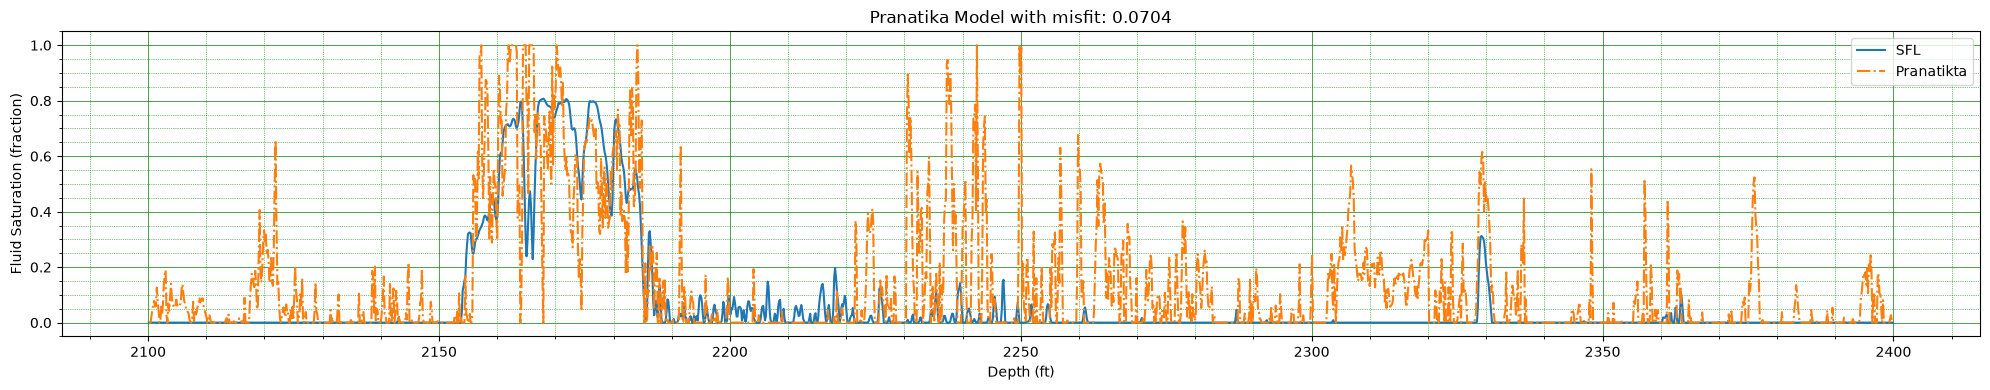

In [39]:
plt.figure(figsize=(20, 4))
plt.plot(well['DEPTH'], (1 - well['SW']), label="SFL")
plt.plot(
    well['DEPTH'],
    np.clip(best_params_pranatikta["Sfl_pranatikta"], 0, 1),
    "-.",
    label="Pranatikta",
)
plt.legend()
plt.xlabel("Depth (ft)")
plt.ylabel("Fluid Saturation (fraction)")
plt.title("Pranatika Model with misfit: {:.4f}".format(best_params_pranatikta["misfit_pranatikta"]))
apply_grid_style()
plt.tight_layout()
plt.show()

In [40]:
print(f'Vp quartz: {Vp_qtz: .2f} m/s')
print(f'Vp shale: {Vp_sh: .2f} m/s')
print(f'VSH reservoir: {Vsh_reservoir: .2f}')
print(f'Rho quartz: {rho_qtz: .2f} g/cm3')
print(f'Rho shale: {rho_shale: .2f} g/cm3')
print(f'')

print('Things to put into the equation for seismic inversion:')
print(f'Vp_matrix_reservoir: {Vp_matrix_reservoir: .2f} m/s')
print(f'Vp water: {Vp_water: .2f} m/s')
print(f'Vp_fluid: {Vp_fluid: .2f} m/s')
print(f'Rho matrix reservoir: {rho_reservoir: .2f} g/cm3')
print(f'Rho fluid: {rho_fluid: .2f} g/cm3')
print(f'Rho water: {rho_water: .2f} g/cm3')
print(f'Vsh: {Vsh_reservoir: .2f}')
print(f'Alpha: {best_params_pranatikta["alpha"]: .2f}')
print(f'N: {best_params_pranatikta["N"]: .2f}')

Vp quartz:  7398.73 m/s
Vp shale:  2149.14 m/s
VSH reservoir:  0.25
Rho quartz:  2.65 g/cm3
Rho shale:  2.81 g/cm3

Things to put into the equation for seismic inversion:
Vp_matrix_reservoir:  4593.59 m/s
Vp water:  1602.75 m/s
Vp_fluid:  1312.10 m/s
Rho matrix reservoir:  2.69 g/cm3
Rho fluid:  0.78 g/cm3
Rho water:  1.09 g/cm3
Vsh:  0.25
Alpha:  0.59
N:  1.70


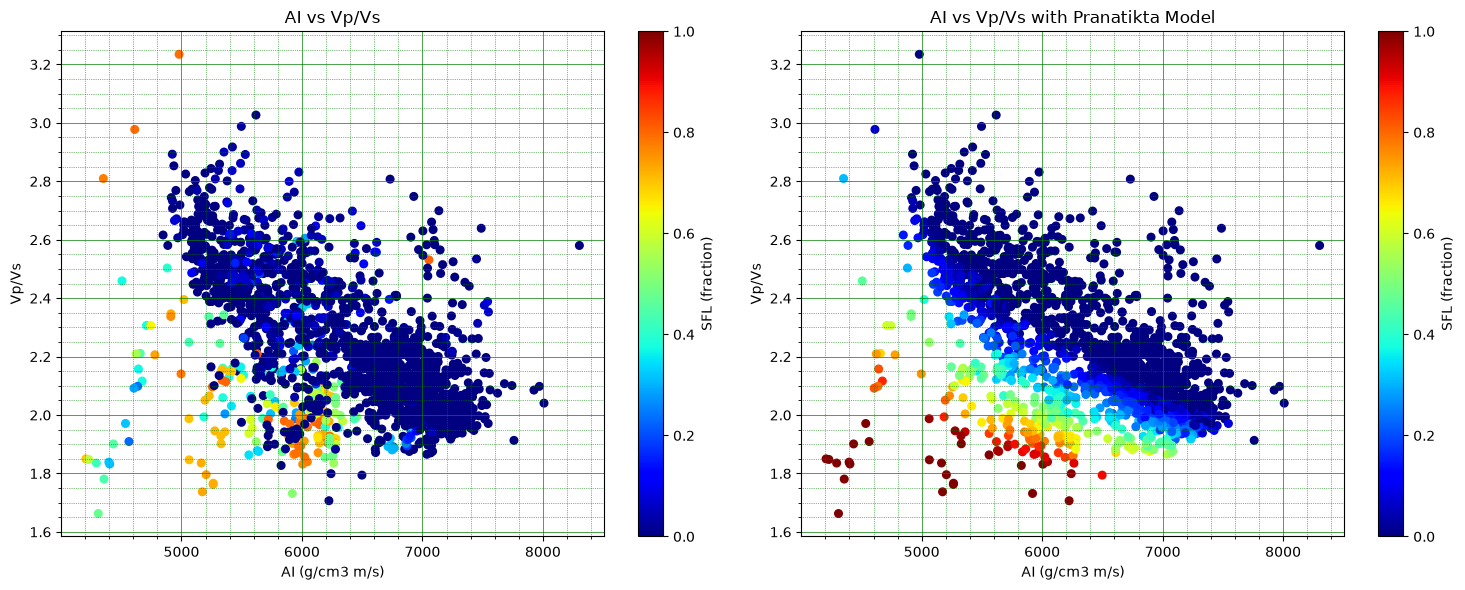

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].scatter(
    well['AI'],
    well['VPVS'],
    c=1 - well['SW'],
    cmap="jet",
    s=30,
    label="well",
    vmin=0,
    vmax=1
)
ax[0].set_xlabel("AI (g/cm3 m/s)")
ax[0].set_ylabel("Vp/Vs")
ax[0].set_title("AI vs Vp/Vs")
apply_grid_style(ax[0])
fig.colorbar(ax[0].collections[0], label="SFL (fraction)")

ax[1].scatter(
    well['AI'],
    well['VPVS'],
    c=best_params_pranatikta["Sfl_pranatikta"],
    cmap="jet",
    s=30,
    label="well",
    vmin=0,
    vmax=1,
)
ax[1].set_xlabel("AI (g/cm3 m/s)")
ax[1].set_ylabel("Vp/Vs")
ax[1].set_title("AI vs Vp/Vs with Pranatikta Model")
apply_grid_style(ax[1])
fig.colorbar(ax[1].collections[0], label="SFL (fraction)")

plt.tight_layout()
plt.show()

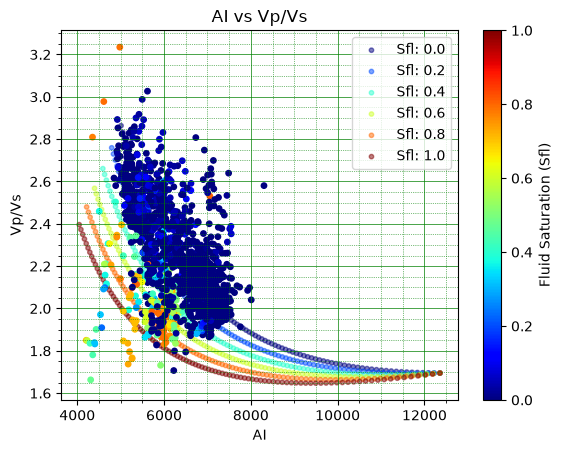

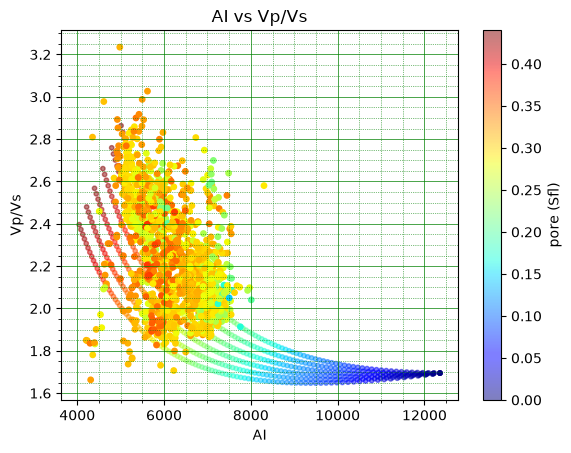

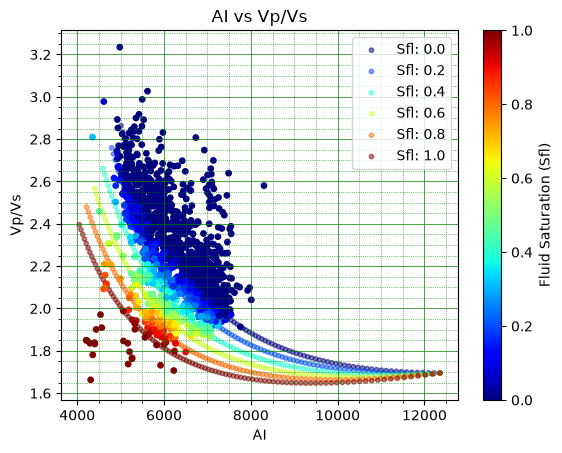

Vp matrix reservoir: 4593.59 m/s
Rho matrix reservoir: 2.69 g/cm3
G: 1.00
Alpha: 0.59
N: 1.70
Vp water: 1602.75 m/s
Vp fluid: 1312.10 m/s
Rho water: 1.09 g/cm3
RHo fluid: 0.78 g/cm3


In [ ]:
SW_last = np.linspace(0, 1, 6)
pore_last = np.linspace(0, 0.44, 101)

G = 1
alpha = best_params_pranatikta["alpha"]
N = best_params_pranatikta["N"]

vsh_reservoir = Vsh_reservoir

rho_matrix = rho_qtz * (1 - vsh_reservoir) + vsh_reservoir * rho_shale
Vp_at_reservoir = wyllie_with_vsh(
    porosity=0,
    Vsh=Vsh_reservoir,
    SW=1,
    Vp_qtz=Vp_qtz,
    Vp_shale=Vp_sh,
    Vp_water=Vp_water,
    Vp_hc=Vp_fluid,
)



curve = {
    "vp": np.zeros((len(SW_last), len(pore_last))),
    "rho": np.zeros((len(SW_last), len(pore_last))),
    "ai": np.zeros((len(SW_last), len(pore_last))),
    "pore": np.zeros((len(SW_last), len(pore_last))),
    "vs": np.zeros((len(SW_last), len(pore_last))),
    "vpvs": np.zeros((len(SW_last), len(pore_last))),
}

for i in range(len(SW_last)):
    for j in range(len(pore_last)):
        vp_visual = (
            ((1 - pore_last[j]) / Vp_at_reservoir)
            + (SW_last[i] * pore_last[j]) / Vp_fluid
            + ((1 - SW_last[i]) * pore_last[j]) / Vp_water
        ) ** -1

        rho_visual = (
            (1 - pore_last[j]) * rho_matrix
            + SW_last[i] * pore_last[j] * rho_fluid
            + (1 - SW_last[i]) * pore_last[j] * rho_water
        )

        ai_visual = vp_visual * rho_visual

        first_part = rho_matrix - (ai_visual / Vp_at_reservoir)
        second_part = ai_visual * (
            (SW_last[i] * (1 / Vp_fluid - 1 / Vp_water))
            + (1 / Vp_water - 1 / Vp_at_reservoir)
        )
        third_part = SW_last[i] * (rho_fluid - rho_water) + (rho_water - rho_matrix)

        pore = first_part / (second_part - third_part)

        rho_dry = (1 - pore) * rho_matrix
        vs_gassmann = G * alpha * Vp_at_reservoir * (1 - pore) ** N

        vs_sat_gassmann = np.sqrt((rho_dry / rho_visual)) * vs_gassmann
        vpvs_visual = vp_visual / vs_sat_gassmann

        curve["vp"][i, j] = vp_visual
        curve["rho"][i, j] = rho_visual
        curve["ai"][i, j] = ai_visual
        curve["pore"][i, j] = pore
        curve["vs"][i, j] = vs_sat_gassmann
        curve["vpvs"][i, j] = vpvs_visual


for k in range(len(SW_last)):
    plt.scatter(
        curve["ai"][k, :],
        curve["vpvs"][k, :],
        label=f"Sfl: {SW_last[k]:.1f}",
        c=np.ones(len(pore_last)) * SW_last[k],
        cmap="jet",
        vmin=0,
        vmax=1,
        alpha=0.5,
        s=10,
    )

plt.scatter(
    well['AI'], well['VPVS'], c=1 - well['SW'], cmap="jet", s=15, vmax=1
)

plt.colorbar(label="Fluid Saturation (Sfl)")
plt.xlabel("AI")
plt.ylabel("Vp/Vs")
plt.title("AI vs Vp/Vs")
plt.legend()
apply_grid_style()
plt.show()

for k in range(len(SW_last)):
    a = plt.scatter(
        curve["ai"][k, :],
        curve["vpvs"][k, :],
        label=f"Sfl: {SW_last[k]}",
        c=np.ones(len(pore_last)) * curve["pore"][k],
        cmap="jet",
        vmin=0,
        alpha=0.5,
        s=10,
    )

plt.scatter(
    well['AI'], well['VPVS'], c=well['PHI'], cmap="jet", s=15,
    vmin=0,
    vmax=0.44
)

plt.colorbar(a, label="pore (Sfl)")
plt.xlabel("AI")
plt.ylabel("Vp/Vs")
plt.title("AI vs Vp/Vs")
apply_grid_style()
plt.show()

for k in range(len(SW_last)):
    plt.scatter(
        curve["ai"][k, :],
        curve["vpvs"][k, :],
        label=f"Sfl: {SW_last[k]:.1f}",
        c=np.ones(len(pore_last)) * SW_last[k],
        cmap="jet",
        vmin=0,
        vmax=1,
        alpha=0.5,
        s=10,
    )

plt.scatter(
    well['AI'],
    well['VPVS'],
    c=best_params_pranatikta["Sfl_pranatikta"],
    cmap="jet",
    s=15,
    vmax=1,
    vmin=0,
)

plt.colorbar(label="Fluid Saturation (Sfl)")
plt.xlabel("AI")
plt.ylabel("Vp/Vs")
plt.title("AI vs Vp/Vs")
plt.legend()
apply_grid_style()
plt.show()


print(f'Vp matrix reservoir: {Vp_at_reservoir:.2f} m/s')
print(f'Rho matrix reservoir: {rho_reservoir:.2f} g/cm3')
print(f'G: {1:.2f}')
print(f'Alpha: {best_params_pranatikta["alpha"]:.2f}')
print(f'N: {best_params_pranatikta["N"]:.2f}')
print(f'Vp water: {Vp_water:.2f} m/s')
print(f'Vp fluid: {Vp_fluid:.2f} m/s')
print(f'Rho water: {rho_water:.2f} g/cm3')
print(f'RHo fluid: {rho_fluid:.2f} g/cm3')

# Important Note:

The quartz and shale P-wave velocities calibrated by multi-linear regression (`Vp_qtz`, `Vp_sh`) are **not** direct measurements of mineral velocity. They are *effective, Wyllie-calibrated* end members: the values that make Wyllie's Time-Average equation best reproduce the observed VP log for this well, given its assumed mixing law.

For comparison, the cells below also compute quartz and shale velocities directly from published elastic moduli (`vp_qtz_modulus`, `vp_sh_modulus`), which represent the physical mineral velocities. The regression-derived quartz end member comes out roughly 20-25% higher than the modulus-based mineral value, while the regression-derived shale end member is correspondingly lower. This divergence is a known limitation of Wyllie's equation: it assumes a simplified series (time-average) mixing law and is documented to require non-physical matrix velocities when calibrated against real, often not fully consolidated well data.
Despite this, the two approaches converge closely once quartz and shale are mixed at the reservoir's characteristic shale fraction (VSH ≈ 0.25, see previous section), because the biases in the two end members run in opposite directions and largely cancel out in the mixture. This is confirmed numerically below and visually in the final Vp model comparison plot.

**Practical takeaway:** the regression-derived end members remain appropriate for the Wyllie-based reservoir and saturation modeling used throughout this notebook, since they are calibrated for exactly that purpose. They should not, however, be cited as physical mineral velocities outside this context use `vp_qtz_modulus` / `vp_sh_modulus` for that.

In [43]:
vp_qtz_modulus = np.sqrt((36.8 + 4 * 44 / 3) / rho_qtz) * 1000
vp_sh_modulus = np.sqrt((15 + 4 * 5 / 3) / rho_shale) * 1000

print(f'Vp matrix quartz from modulus: {vp_qtz_modulus}')
print(f'Vp matrix quartz from MLR: {Vp_qtz}')

print(f'Vp matrix shale from modulus: {vp_sh_modulus}')
print(f'Vp matrix shale from MLR: {Vp_sh}')

print(f'Vp matrix MLR at reservoir : {wyllie_with_vsh(porosity=0, Vsh=Vsh_reservoir, SW=1, Vp_qtz=Vp_qtz, Vp_shale=Vp_sh, Vp_water=Vp_water, Vp_hc=Vp_fluid)}')
print(f'Vp matrix modulus at reservoir: {wyllie_with_vsh(porosity=0, Vsh=Vsh_reservoir, SW=1, Vp_qtz=vp_qtz_modulus, Vp_shale=vp_sh_modulus, Vp_water=Vp_water, Vp_hc=Vp_fluid)}')

Vp matrix quartz from modulus: 6002.096069932936
Vp matrix quartz from MLR: 7398.728445183855
Vp matrix shale from modulus: 2776.789068802597
Vp matrix shale from MLR: 2149.1367894126715
Vp matrix MLR at reservoir : 4593.592397327401
Vp matrix modulus at reservoir: 4651.4139085652005


In [44]:
print(f'Vp quartz MLR / modulus = {Vp_qtz / (vp_qtz_modulus)}')
print(f'Vp shale MLR / modulus = { Vp_sh / (vp_sh_modulus) }')

Vp quartz MLR / modulus = 1.232690773186262
Vp shale MLR / modulus = 0.7739647255019696


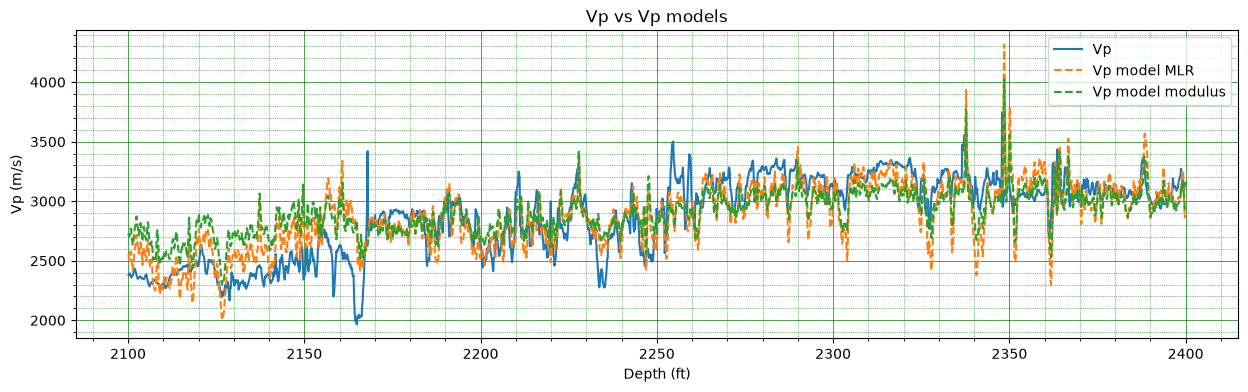

In [71]:
Vp_matrix = 1 / (((1 - well['VSH']) / Vp_qtz) + (well['VSH'] / Vp_sh)) 
Vp_fluid = best_Vp_fluid['Vp_fluid']

Vp_model = (((1 - well['PHI']) / Vp_matrix) + (well['PHI'] * well['SW'] / Vp_water) + (well['PHI'] * (1 - well['SW']) / Vp_fluid)) ** -1

Vp_matrix2 = 1 / (((1 - well['VSH']) / (vp_qtz_modulus)) + (well['VSH'] / (vp_sh_modulus))) 
Vp_fluid2 = best_Vp_fluid['Vp_fluid']

Vp_model2 = (((1 - well['PHI']) / Vp_matrix2) + (well['PHI'] * well['SW'] / Vp_water) + (well['PHI'] * (1 - well['SW']) / Vp_fluid)) ** -1

        



depth_comparison_plot(
    well['DEPTH'],
    {"Vp": well['VP'], "Vp model MLR": Vp_model, "Vp model modulus":Vp_model2},
    xlabel="Depth (ft)", ylabel="Vp (m/s)", title="Vp vs Vp models",
    linestyles={"Vp model MLR": "--", 'Vp model modulus': '--'},
)
plt.show()
